# Modelling Script

In [1]:
#standard packages
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import date

#modelling packages
import statsmodels.api as sm
import xgboost as xgb

#custom 
from actuals_vs_pred_graph import actuals_vs_pred_graph_func

In [2]:
path = os.path.abspath(os.path.join(os.getcwd(),"..",'final features','final_features.parquet'))
data = pd.read_parquet(path)

#plan is to start simple and work up to more flexible models


## 1.OLS Model

In [3]:
ols_data = data.dropna()
#select X 
x_list = [ 'mean_temp_c',
            'elec_price_audmwh',
            'temp_deviation',
            'state_population',
            'solar_exposure',
            'average_max_temp',
            't',
            'QLD',
            'VIC']
feature_list =['net_electricity_gwh'] + x_list


#select exogenous and endogenous variables
X = ols_data[x_list]
y = ols_data['net_electricity_gwh']

#add constant
X['const'] = 1

#fit and summarize
model = sm.OLS(y, X).fit()
print(model.summary())
ols_data['predicted'] = model.predict(X)

#mean_temp, elec_price and solar are not significant looking linearly, can still explain 83% of the variance though.

                             OLS Regression Results                            
Dep. Variable:     net_electricity_gwh   R-squared:                       0.830
Model:                             OLS   Adj. R-squared:                  0.828
Method:                  Least Squares   F-statistic:                     380.0
Date:                 Sat, 14 Feb 2026   Prob (F-statistic):          3.58e-262
Time:                         00:12:12   Log-Likelihood:                -5220.4
No. Observations:                  708   AIC:                         1.046e+04
Df Residuals:                      698   BIC:                         1.051e+04
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
mean_temp_c          13.8434

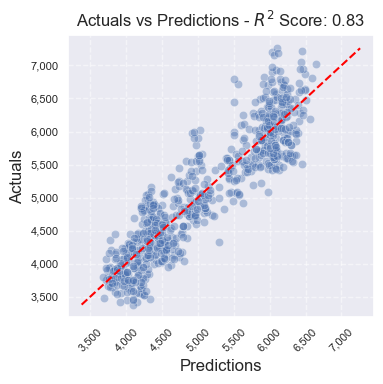

In [4]:
#compare graphically, the closer the points are to the 45 degree line the better fitting model
actuals_vs_pred_graph_func(y_actual = ols_data['net_electricity_gwh'], y_pred = ols_data['predicted'])